In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [ ]:
df = pd.read_csv("/home/prajwalmac/7th Semester/Project/Project Demo/AgroTree/data/raw/raw_data.csv")

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,140.519666,60.389968,19.369833,NaN,72.395542,7.916508,88.940006,cotton
1,NaN,21.072573,46.585469,30.119153,97.008824,6.479308,24.650713,muskmelon
2,51.668481,69.188181,21.245128,32.607020,NaN,7.111532,69.328985,blackgram
3,65.133280,62.570254,53.838735,30.443243,89.327208,6.326934,199.862354,papaya
4,5.879597,134.514423,197.421709,20.941375,92.824389,5.980268,NaN,apple


In [13]:
df.shape

(21273, 8)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21273 entries, 0 to 21272
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            20226 non-null  float64
 1   P            20197 non-null  float64
 2   K            20201 non-null  float64
 3   temperature  20225 non-null  float64
 4   humidity     20193 non-null  float64
 5   ph           20220 non-null  float64
 6   rainfall     20196 non-null  float64
 7   label        21273 non-null  object 
dtypes: float64(7), object(1)
memory usage: 1.3+ MB


In [15]:
df.isnull().sum()

N              1047
P              1076
K              1072
temperature    1048
humidity       1080
ph             1053
rainfall       1077
label             0
dtype: int64

In [16]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,20226.000000,20197.000000,20201.000000,20225.000000,20193.000000,20220.000000,20196.000000
mean,50.657108,54.105815,51.626018,25.571138,72.765348,6.435002,102.668147
std,37.534206,35.334197,54.002302,5.361241,23.205424,0.788607,58.931233
min,0.000000,4.268002,4.364344,8.217962,12.905807,2.923178,17.630640
25%,20.378642,25.462353,20.407731,22.377992,61.306712,5.920874,62.371382
50%,36.463113,51.429654,35.650869,25.587495,81.233378,6.390613,96.657316
75%,86.296653,70.477597,50.665224,28.605390,89.477897,6.909774,121.763143
max,154.433076,168.387282,235.368165,51.960683,113.149599,10.879153,845.689962


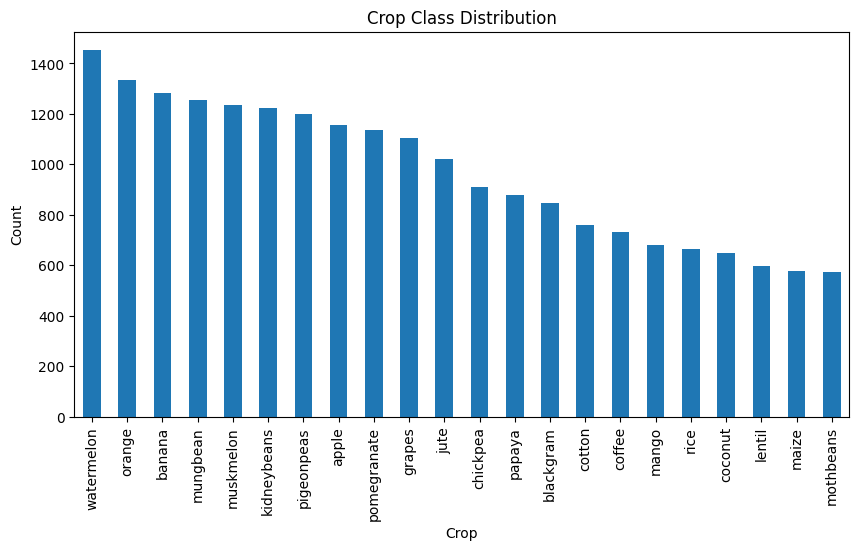

In [17]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Crop Class Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.show()


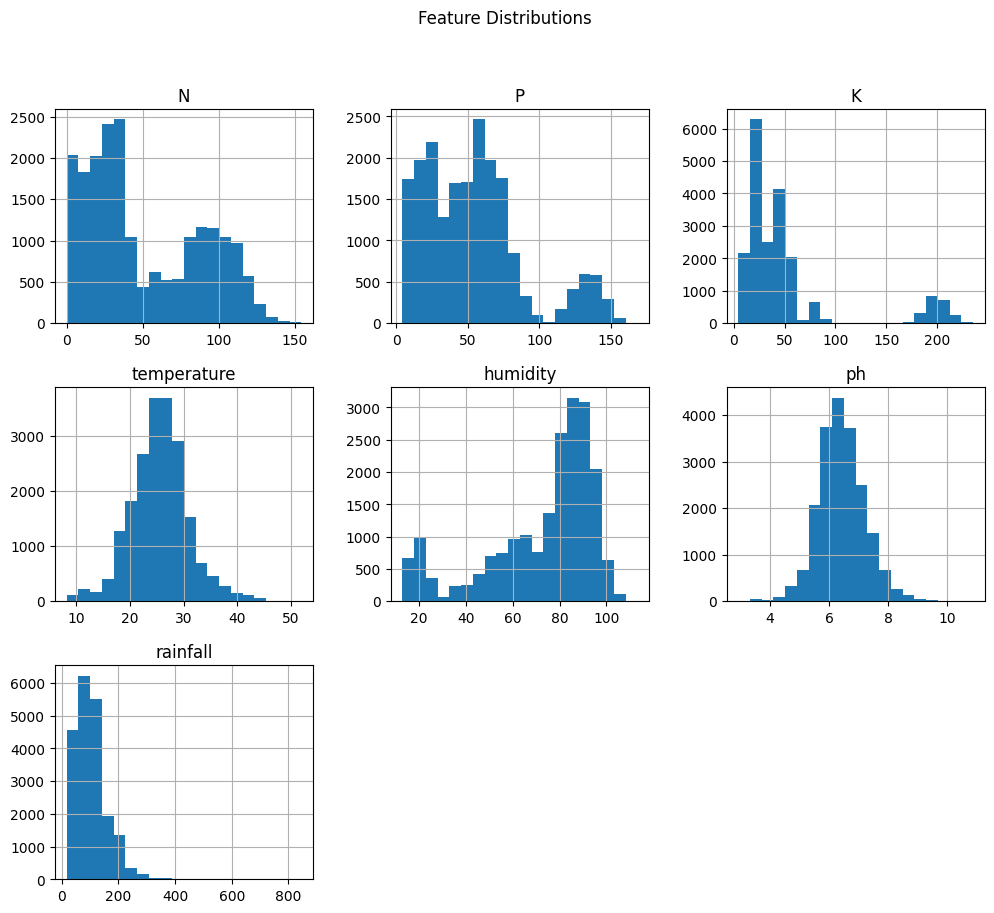

In [16]:
df.drop(columns=["label"]).hist(figsize=(12,10), bins=20)
plt.suptitle("Feature Distributions")
plt.show()


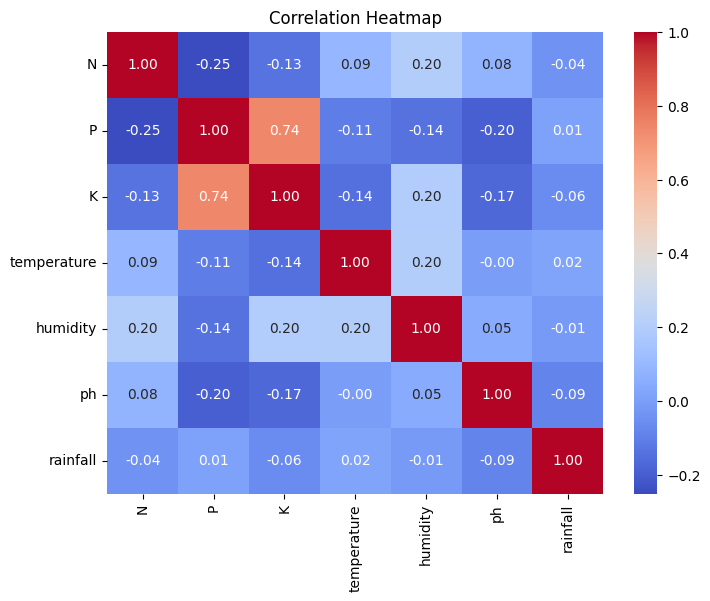

In [17]:
import seaborn as sns

corr = df.drop(columns=["label"]).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [19]:
# ============================================================
# EDA SECTION 2: DESCRIPTIVE STATISTICS
# ============================================================

import pandas as pd
import numpy as np

df = pd.read_csv("/home/prajwalmac/7th Semester/Project/Project Demo/AgroTree/data/processed/data.csv")

FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

print("=" * 60)
print("2.1  OVERALL DESCRIPTIVE STATISTICS")
print("=" * 60)
print(df[FEATURES].describe().round(3).T)

print("\n" + "=" * 60)
print("2.2  SKEWNESS & KURTOSIS")
print("=" * 60)
skew_kurt = pd.DataFrame({
    "Skewness" : df[FEATURES].skew().round(4),
    "Kurtosis" : df[FEATURES].kurt().round(4)
})
print(skew_kurt)
print("\n  Skewness > |1|  → highly skewed")
print("  Kurtosis > 3    → heavy-tailed (leptokurtic)")

print("\n" + "=" * 60)
print("2.3  PER-CROP MEAN VALUES (Top 5 crops shown)")
print("=" * 60)
crop_means = df.groupby("label")[FEATURES].mean().round(2)
print(crop_means.head(5))
print("\n... use crop_means.to_csv('crop_means.csv') to export full table")

print("\n" + "=" * 60)
print("2.4  PER-CROP STD DEVIATION")
print("=" * 60)
crop_std = df.groupby("label")[FEATURES].std().round(2)
print(crop_std.head(5))

print("\n" + "=" * 60)
print("2.5  FEATURE RANGE SUMMARY (Min / Max / Range)")
print("=" * 60)
range_df = pd.DataFrame({
    "Min"  : df[FEATURES].min().round(2),
    "Max"  : df[FEATURES].max().round(2),
    "Range": (df[FEATURES].max() - df[FEATURES].min()).round(2)
})
print(range_df)

2.1  OVERALL DESCRIPTIVE STATISTICS
               count     mean     std     min     25%     50%      75%  \
N            20226.0   50.657  37.534   0.000  20.379  36.463   86.297   
P            20197.0   54.106  35.334   4.268  25.462  51.430   70.478   
K            20201.0   51.626  54.002   4.364  20.408  35.651   50.665   
temperature  20225.0   25.571   5.361   8.218  22.378  25.587   28.605   
humidity     20193.0   72.765  23.205  12.906  61.307  81.233   89.478   
ph           20220.0    6.435   0.789   2.923   5.921   6.391    6.910   
rainfall     20196.0  102.668  58.931  17.631  62.371  96.657  121.763   

                 max  
N            154.433  
P            168.387  
K            235.368  
temperature   51.961  
humidity     113.150  
ph            10.879  
rainfall     845.690  

2.2  SKEWNESS & KURTOSIS
             Skewness  Kurtosis
N              0.5044   -1.1055
P              0.9348    0.4593
K              2.1498    3.3480
temperature    0.1818    1.0516
h

7.1  OUTLIERS — IQR METHOD  (1.5 × IQR rule)
                Q1      Q3    IQR  Lower Fence  Upper Fence  Outliers  \
Feature                                                                 
N            20.38   86.30  65.92       -78.50       185.17         0   
P            25.46   70.48  45.02       -42.06       138.00       748   
K            20.41   50.67  30.26       -24.98        96.05      2161   
temperature  22.38   28.61   6.23        13.04        37.95       796   
humidity     61.31   89.48  28.17        19.05       131.73       928   
ph            5.92    6.91   0.99         4.44         8.39       385   
rainfall     62.37  121.76  59.39       -26.72       210.85       854   

             Outlier %  
Feature                 
N                 0.00  
P                 3.70  
K                10.70  
temperature       3.94  
humidity          4.60  
ph                1.90  
rainfall          4.23  

7.2  OUTLIERS — Z-SCORE METHOD  (|Z| > 3)
  N             Outliers:    

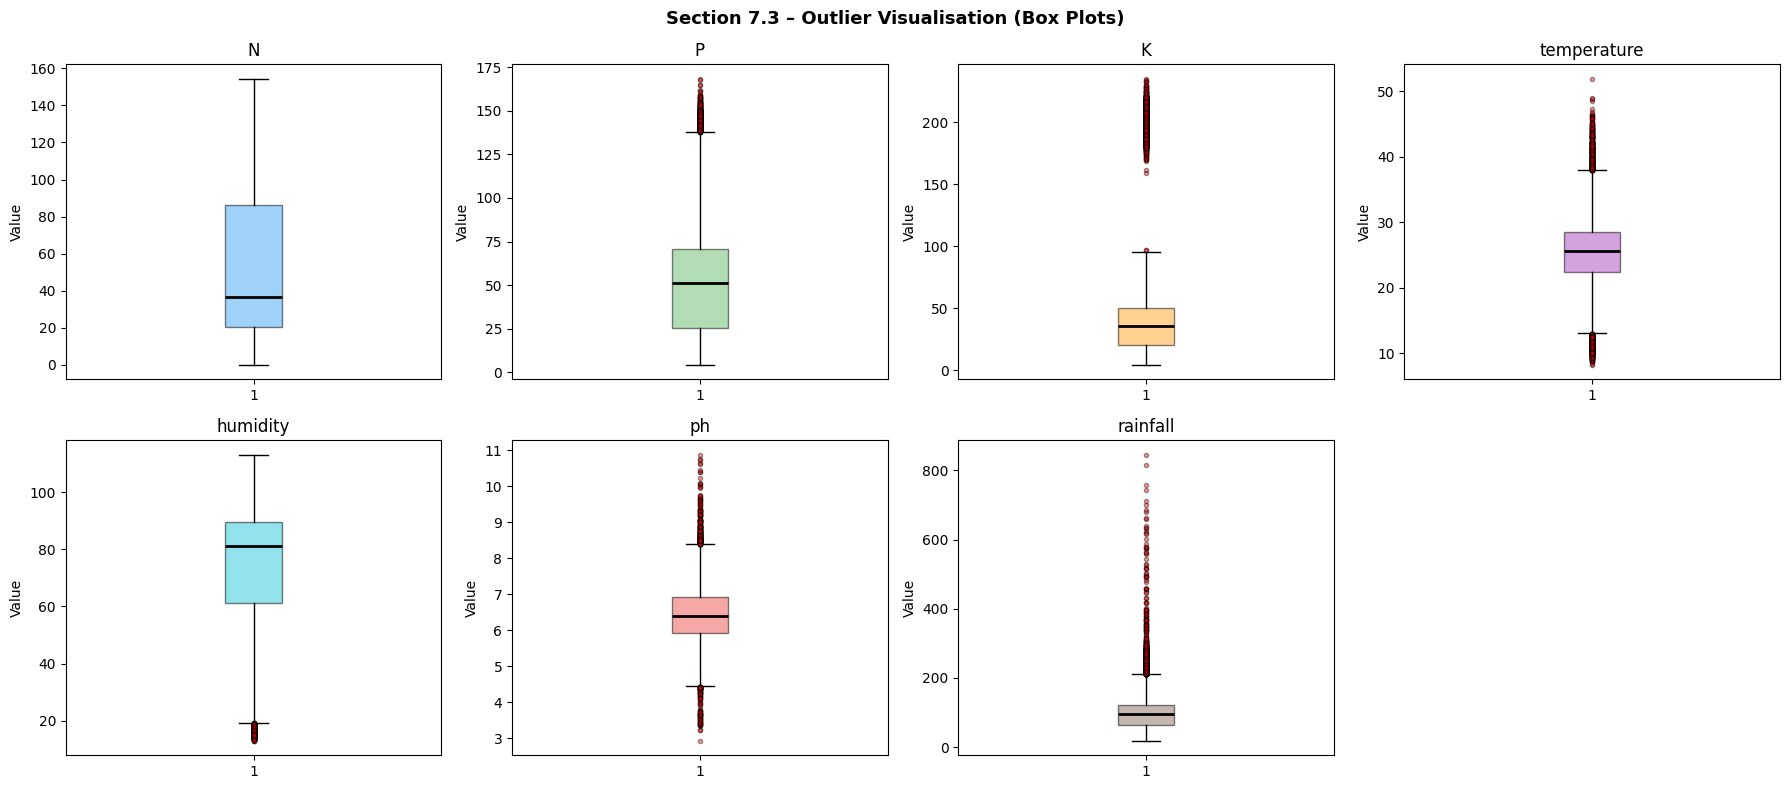


Plot saved → results/eda_section7_outliers.png

7.4  SAMPLE OUTLIER ROWS (N column, IQR method)
Empty DataFrame
Columns: [N, P, K, temperature, humidity, ph, rainfall, label]
Index: []


In [20]:
# ============================================================
# EDA SECTION 7: OUTLIER DETECTION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("/home/prajwalmac/7th Semester/Project/Project Demo/AgroTree/data/processed/data.csv")

FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

# -----------------------------------------------------------
# 7.1  IQR Method — Count & Percentage of Outliers
# -----------------------------------------------------------
print("=" * 60)
print("7.1  OUTLIERS — IQR METHOD  (1.5 × IQR rule)")
print("=" * 60)

iqr_summary = []
for col in FEATURES:
    data  = df[col].dropna()
    Q1, Q3 = np.percentile(data, 25), np.percentile(data, 75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((data < lower) | (data > upper)).sum()
    pct   = n_out / len(data) * 100
    iqr_summary.append({
        "Feature": col, "Q1": round(Q1,2), "Q3": round(Q3,2),
        "IQR": round(IQR,2), "Lower Fence": round(lower,2),
        "Upper Fence": round(upper,2), "Outliers": n_out, "Outlier %": round(pct,2)
    })

iqr_df = pd.DataFrame(iqr_summary).set_index("Feature")
print(iqr_df)

# -----------------------------------------------------------
# 7.2  Z-Score Method  (|Z| > 3)
# -----------------------------------------------------------
print("\n" + "=" * 60)
print("7.2  OUTLIERS — Z-SCORE METHOD  (|Z| > 3)")
print("=" * 60)

for col in FEATURES:
    data  = df[col].dropna()
    z     = np.abs(stats.zscore(data))
    n_out = (z > 3).sum()
    pct   = n_out / len(data) * 100
    print(f"  {col:<12}  Outliers: {n_out:>4}  ({pct:.2f}%)")

# -----------------------------------------------------------
# 7.3  Visual — Combined Box Plots in one figure
# -----------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Section 7.3 – Outlier Visualisation (Box Plots)", fontsize=13, fontweight="bold")
axes = axes.flatten()

colors = ["#42a5f5","#66bb6a","#ffa726","#ab47bc","#26c6da","#ef5350","#8d6e63"]

for i, (col, color) in enumerate(zip(FEATURES, colors)):
    data = df[col].dropna()
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.5),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.4),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig("results/eda_section7_outliers.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved → results/eda_section7_outliers.png")

# -----------------------------------------------------------
# 7.4  Outlier Rows for Inspection
# -----------------------------------------------------------
print("\n" + "=" * 60)
print("7.4  SAMPLE OUTLIER ROWS (N column, IQR method)")
print("=" * 60)
col  = "N"
data = df[col].dropna()
Q1, Q3 = np.percentile(data, 25), np.percentile(data, 75)
IQR    = Q3 - Q1
outlier_mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
print(df[outlier_mask].head(10))

8.1  FEATURE IMPORTANCE — Random Forest
    Feature  Importance
   rainfall    0.253753
          K    0.200775
   humidity    0.178089
          P    0.155664
          N    0.107197
temperature    0.062752
         ph    0.041770


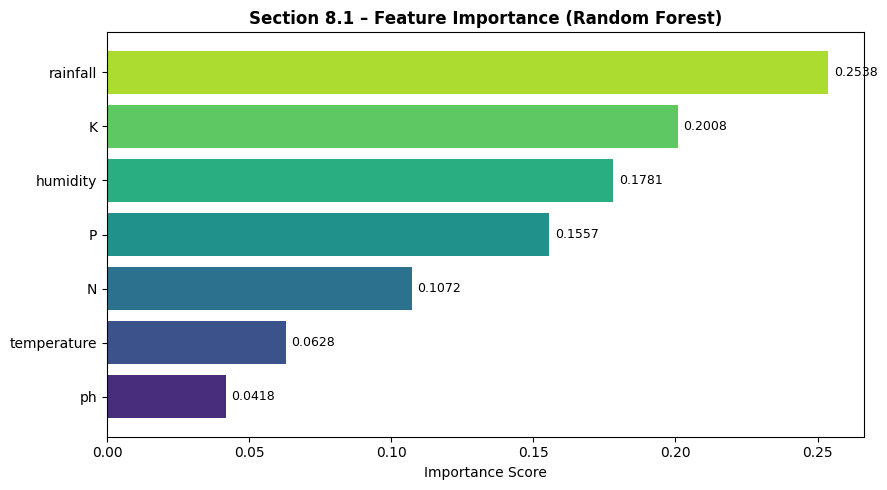


8.2  MUTUAL INFORMATION SCORES
    Feature  MI Score
          K  1.555778
   rainfall  1.391201
          P  1.283688
   humidity  1.203510
          N  0.932560
temperature  0.656069
         ph  0.384529

8.3  EDA FINAL SUMMARY
  Total Rows                          : 21273
  Total Features                      : 7
  Target Classes                      : 22
  Missing Values                      : 7453
  Duplicate Rows                      : 0
  Most Important Feature (RF)         : rainfall
  Most Important Feature (MI)         : K
  Largest Class                       : watermelon
  Smallest Class                      : mothbeans

✅ EDA Complete. All plots saved to results/


In [23]:
# ============================================================
# EDA SECTION 8: FEATURE IMPORTANCE & EDA SUMMARY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder


FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

# Use clean data (drop nulls for this section)
df_clean = df.dropna()
X = df_clean[FEATURES].values
le = LabelEncoder()
y = le.fit_transform(df_clean["label"].values)

# -----------------------------------------------------------
# 8.1  Random Forest Feature Importance
# -----------------------------------------------------------
print("=" * 60)
print("8.1  FEATURE IMPORTANCE — Random Forest")
print("=" * 60)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importance_df = pd.DataFrame({
    "Feature"   : FEATURES,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1],
    color=sns.color_palette("viridis", len(FEATURES))
)
ax.set_xlabel("Importance Score")
ax.set_title("Section 8.1 – Feature Importance (Random Forest)", fontsize=12, fontweight="bold")

for bar, val in zip(bars, importance_df["Importance"][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()
# -----------------------------------------------------------
# 8.2  Mutual Information (non-linear feature relevance)
# -----------------------------------------------------------
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({
    "Feature": FEATURES,
    "MI Score": mi_scores
}).sort_values("MI Score", ascending=False)

print("\n" + "=" * 60)
print("8.2  MUTUAL INFORMATION SCORES")
print("=" * 60)
print(mi_df.to_string(index=False))

# -----------------------------------------------------------
# 8.3  EDA Summary Table
# -----------------------------------------------------------
print("\n" + "=" * 60)
print("8.3  EDA FINAL SUMMARY")
print("=" * 60)

summary = {
    "Total Rows"       : len(df),
    "Total Features"   : len(FEATURES),
    "Target Classes"   : df["label"].nunique(),
    "Missing Values"   : df.isnull().sum().sum(),
    "Duplicate Rows"   : df.duplicated().sum(),
    "Most Important Feature (RF)" : importance_df.iloc[0]["Feature"],
    "Most Important Feature (MI)" : mi_df.iloc[0]["Feature"],
    "Largest Class"    : df["label"].value_counts().idxmax(),
    "Smallest Class"   : df["label"].value_counts().idxmin(),
}

for k, v in summary.items():
    print(f"  {k:<35} : {v}")

print("\n✅ EDA Complete. All plots saved to results/")

In [7]:
df[df.isnull().any(axis=1)]

,N,P,K,temperature,humidity,ph,rainfall,label
0,140.519666,60.389968,19.369833,NaN,72.395542,7.916508,88.940006,cotton
1,NaN,21.072573,46.585469,30.119153,97.008824,6.479308,24.650713,muskmelon
2,51.668481,69.188181,21.245128,32.607020,NaN,7.111532,69.328985,blackgram
4,5.879597,134.514423,197.421709,20.941375,92.824389,5.980268,NaN,apple
9,27.898047,125.891498,184.148919,NaN,91.453344,5.812053,105.649086,apple
...,...,...,...,...,...,...,...,...
21262,25.099117,63.465430,NaN,27.010866,64.711343,6.710050,35.481776,lentil
21264,34.305594,135.989953,NaN,21.921260,92.671688,5.703269,114.724381,apple
21267,NaN,NaN,216.503620,20.797541,89.543232,6.152479,108.835682,apple
21269,62.726252,69.418253,49.908189,22.795333,89.399092,NaN,85.619862,papaya


In [8]:
# 1. Missing count and % per column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
print(pd.DataFrame({"Missing": missing, "%": missing_pct.round(2)}))

# 2. How many rows have at least one null
rows_with_null = df.isnull().any(axis=1).sum()
print(f"Rows with at least one null: {rows_with_null} ({rows_with_null/len(df)*100:.1f}%)")

# 3. Distribution of nulls per row (are they concentrated or spread?)
df.isnull().sum(axis=1).value_counts().sort_index()

             Missing     %
N               1047  4.92
P               1076  5.06
K               1072  5.04
temperature     1048  4.93
humidity        1080  5.08
ph              1053  4.95
rainfall        1077  5.06
label              0  0.00
Rows with at least one null: 6426 (30.2%)


0    14847
1     5489
2      852
3       80
4        5
Name: count, dtype: int64

In [9]:
# Confirm how many values are missing per row
df.isnull().sum(axis=1).value_counts().sort_index()

0    14847
1     5489
2      852
3       80
4        5
Name: count, dtype: int64

In [11]:
# If df is still loaded in your session, save it immediately
df.to_csv("crop_dataset_recovered.csv", index=False)

In [22]:
import sys
import os
sys.path.insert(0, "/home/prajwalmac/7th Semester/Project/Project Demo/AgroTree")

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

from src.preprocess import full_pipeline
from src.model import DecisionTreeCART
from src.config import DATASET_PATH, SCALER_PATH

# ── 1. Reload pipeline (uses cache — fast) ────────────────────────────────────
X_train, X_test, y_train, y_test, scaler, crop_medians, fences = full_pipeline(
    path             = DATASET_PATH,
    scaler_save_path = SCALER_PATH,
)

# ── 2. Retrain model ──────────────────────────────────────────────────────────
model = DecisionTreeCART()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ── 3. Accuracy ───────────────────────────────────────────────────────────────
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

# ── 4. Confusion matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=model.classes_,
            yticklabels=model.classes_,
            cmap="Blues")
plt.title("Confusion Matrix", fontsize=16)
plt.ylabel("Actual", fontsize=12)
plt.xlabel("Predicted", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ── 5. Rice-specific confusion ────────────────────────────────────────────────
rice_idx = list(model.classes_).index("rice")
rice_row  = cm[rice_idx]

print("\nRice confusion breakdown:")
for crop, count in zip(model.classes_, rice_row):
    if count > 0:
        print(f"  Actual rice → Predicted {crop:15s} : {count}")

Processed dataset found. Loading from: /home/prajwalmac/7th Semester/Project/Project Demo/AgroTree/data/processed/processed_data.csv
  loaded rows: 20281

[Step 5] Scaling and splitting...
  scaler fitted and saved to: /home/prajwalmac/7th Semester/Project/Project Demo/AgroTree/models/scaler.pkl
  train size: 16224 | test size: 4057
Accuracy : 0.9744

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00       220
      banana       1.00      1.00      1.00       244
   blackgram       0.94      0.98      0.96       164
    chickpea       1.00      1.00      1.00       175
     coconut       0.98      0.99      0.99       122
      coffee       0.98      0.96      0.97       139
      cotton       0.94      0.97      0.96       145
      grapes       1.00      1.00      1.00       211
        jute       0.87      0.93      0.90       197
 kidneybeans       1.00      0.99      0.99       231
      lentil       0.96     

AttributeError: 'DecisionTreeCART' object has no attribute 'classes_'

Rice confusion breakdown (actual rice → predicted as):
  ✗ jute            : 24
  ✗ papaya          : 1
  ✓ rice            : 101

False positives (other crops predicted as rice):
  ✗ coffee          → predicted rice : 3
  ✗ jute            → predicted rice : 8
  ✗ papaya          → predicted rice : 2


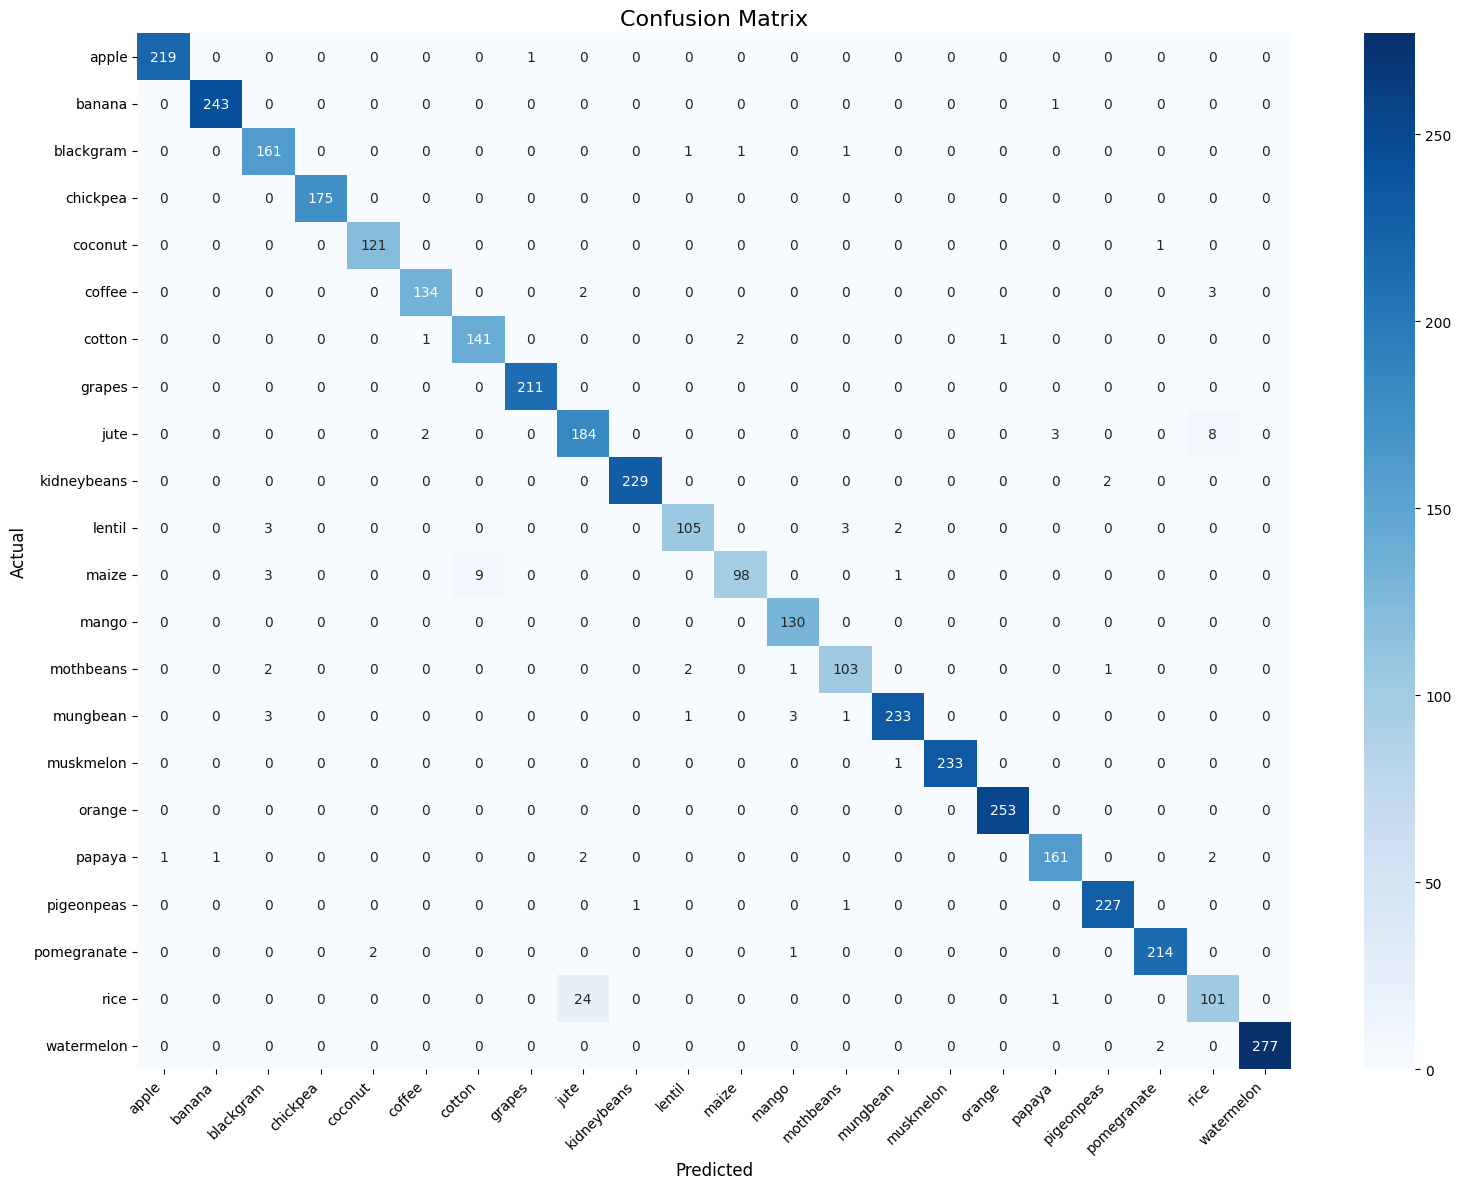

In [24]:
import numpy as np

# ── Derive classes from data directly ─────────────────────────────────────────
classes = np.unique(np.concatenate([y_train, y_test]))

cm = confusion_matrix(y_test, y_pred, labels=classes)

# ── Rice confusion breakdown ──────────────────────────────────────────────────
rice_idx = list(classes).index("rice")
rice_row  = cm[rice_idx]

print("Rice confusion breakdown (actual rice → predicted as):")
for crop, count in zip(classes, rice_row):
    if count > 0:
        marker = "✓" if crop == "rice" else "✗"
        print(f"  {marker} {crop:15s} : {count}")

# ── False positives (other crops predicted as rice) ───────────────────────────
rice_col = cm[:, rice_idx]
print("\nFalse positives (other crops predicted as rice):")
for crop, count in zip(classes, rice_col):
    if count > 0 and crop != "rice":
        print(f"  ✗ {crop:15s} → predicted rice : {count}")

# ── Confusion matrix heatmap ──────────────────────────────────────────────────
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=classes,
            yticklabels=classes,
            cmap="Blues")
plt.title("Confusion Matrix", fontsize=16)
plt.ylabel("Actual", fontsize=12)
plt.xlabel("Predicted", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Feature means — rice vs jute:
label          jute    rice
N            77.609  80.765
P            46.595  47.784
K             3.715   3.702
temperature  24.953  23.750
humidity     79.700  82.280
ph            6.760   6.430
rainfall      5.169   5.458


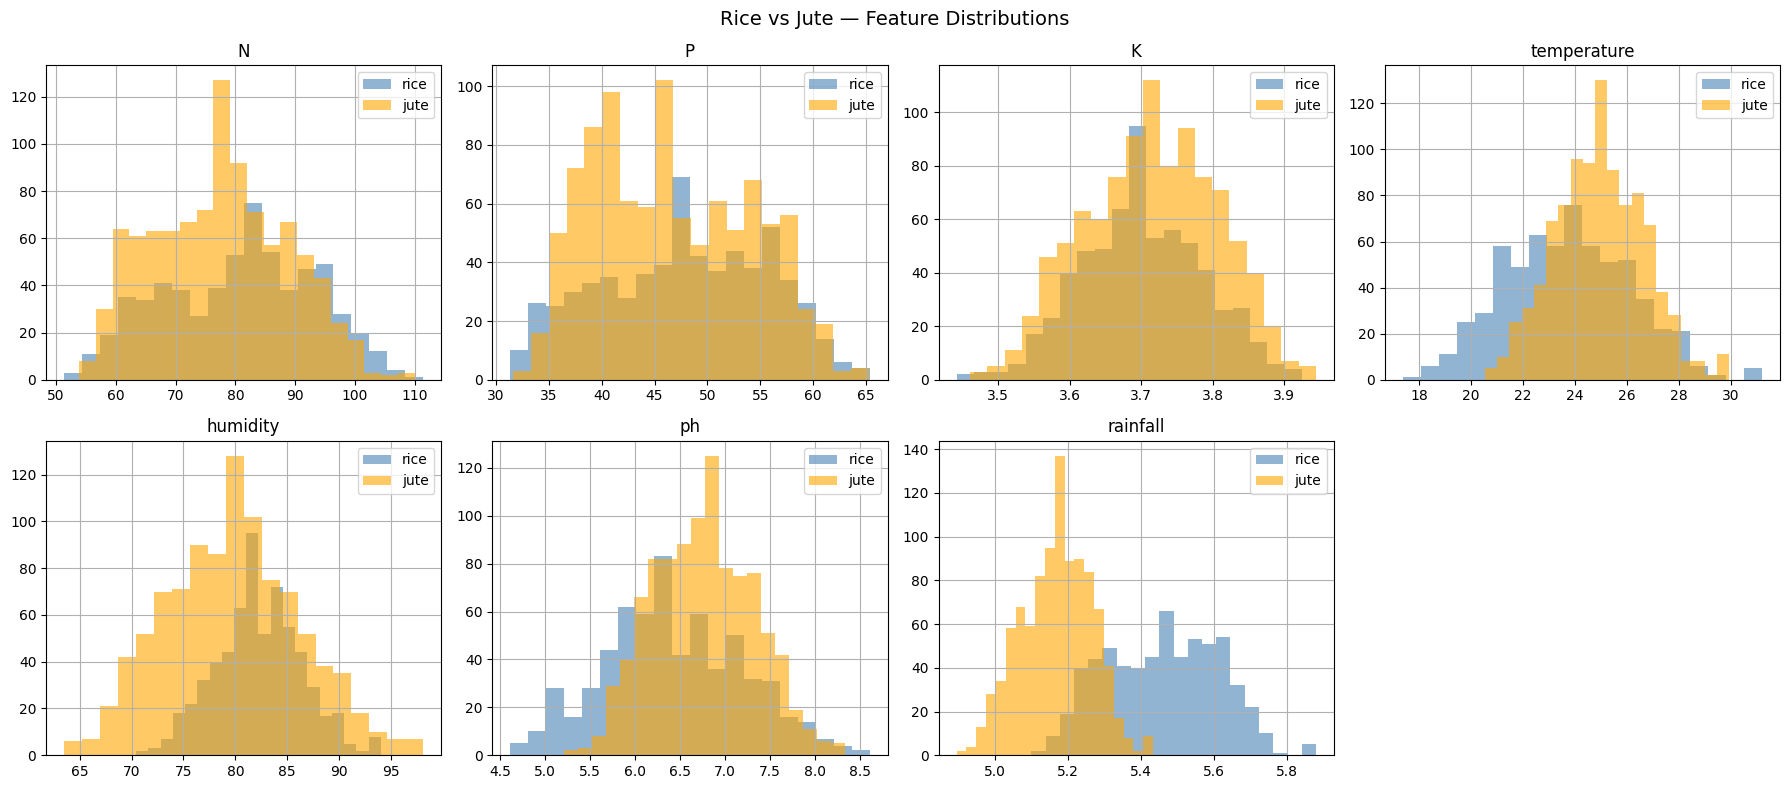

In [25]:
df = pd.read_csv("/home/prajwalmac/7th Semester/Project/Project Demo/AgroTree/data/processed/processed_data.csv")

features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

# ── 1. Side-by-side stats ─────────────────────────────────────────────────────
comparison = df[df["label"].isin(["rice", "jute"])].groupby("label")[features].mean().T
print("Feature means — rice vs jute:")
print(comparison.round(3))

# ── 2. Distribution plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(features):
    ax = axes[i // 4][i % 4]
    df[df["label"] == "rice"][col].hist(ax=ax, alpha=0.6, label="rice", bins=20, color="steelblue")
    df[df["label"] == "jute"][col].hist(ax=ax, alpha=0.6, label="jute", bins=20, color="orange")
    ax.set_title(col)
    ax.legend()

axes[1][3].axis("off")
plt.suptitle("Rice vs Jute — Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

In [26]:
print("Feature means — rice vs jute (original scale):")
comparison_orig = np.expm1(comparison)  # reverse log1p for K and rainfall
# but only K and rainfall were transformed, so:

raw_comparison = df[df["label"].isin(["rice", "jute"])].groupby("label")[features].mean()
raw_comparison["K"]        = np.expm1(raw_comparison["K"])
raw_comparison["rainfall"] = np.expm1(raw_comparison["rainfall"])
print(raw_comparison.T.round(2))

Feature means — rice vs jute (original scale):
label          jute    rice
N             77.61   80.76
P             46.60   47.78
K             40.04   39.53
temperature   24.95   23.75
humidity      79.70   82.28
ph             6.76    6.43
rainfall     174.73  233.65
